# Netflix Dataset Exploratory Data Analysis

This notebook presents an Exploratory Data Analysis (EDA) of the Netflix dataset using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn.

The dataset was cleaned and preprocessed to handle missing values, remove inconsistencies, and improve overall data quality. After understanding the structure of the dataset, both univariate and bivariate analyses were performed using various visualizations to identify patterns, trends, and relationships within Netflix’s content library.

The goal is to gain insights into content distribution, ratings, release years, genres, and other key characteristics of Netflix titles.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading

In [9]:
df = pd.read_csv(r"C:\Users\SATYAM SINGH\OneDrive\Desktop\Netflix_Dataset\\netflix_titles.csv")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Data Overview

In [10]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [13]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [15]:
df.shape

(8807, 12)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [17]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [19]:
df.duplicated(subset=["show_id"]).sum()

0

#### Data Cleaning

In [20]:
# removing extra spaces between columns
df.columns = df.columns.str.strip()

In [21]:
df["director"] = df["director"].replace("rajiv Chilaka","Rajiv Shukla")

In [22]:
# filling missing values in columns (director, cast, country) with "Unknown"

df[["director","cast","country"]] = df[["director","cast","country"]].fillna("Unknown")

In [23]:
df["date_added"]= df["date_added"].fillna(df["date_added"].mode()[0])

In [24]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [25]:
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [26]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [27]:
# Data is Cleaned and ready for Analysis

### EDA with Visualization
##### 1. Distribution of type (movies and TV shows)

In [29]:
# How many movies and shows
type_dist = df["type"].value_counts()
type_dist

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

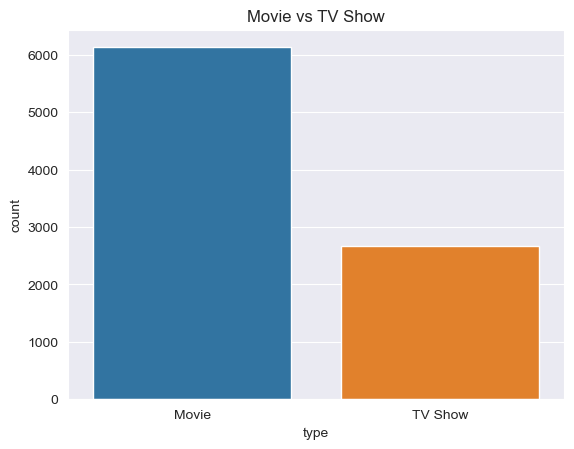

In [31]:
sns.set_style("darkgrid")
sns.countplot(x="type",data=df)
plt.title("Movie vs TV Show")
plt.show()

#### Insight:

Movies(6131) are more than TV shows (2676).


##### 2. Distibution of release year

In [32]:
# Which years have most release
releases = df["release_year"].value_counts()


In [33]:
releases

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: count, Length: 74, dtype: int64

C:\Users\SATYAM SINGH\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


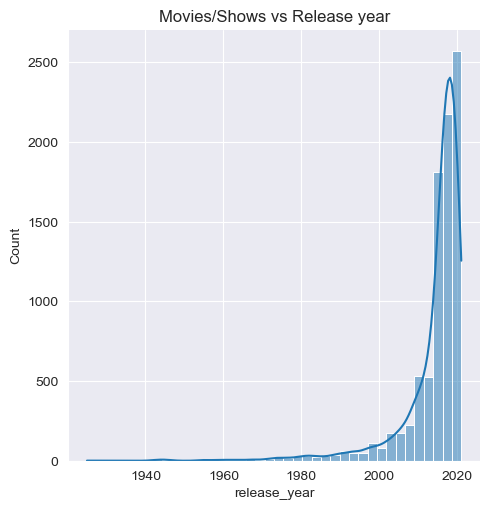

In [38]:
sns.displot(x="release_year", data=df,bins=40,kde=True)
plt.title("Movies/Shows vs Release year")
plt.show()

#### Insight:

Most released years are between 2015-2020 while before 2000 released date is lowest.

##### 3.Distribution of rating

In [41]:
# which rating is most common
rating = df["rating"].value_counts()
rating

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

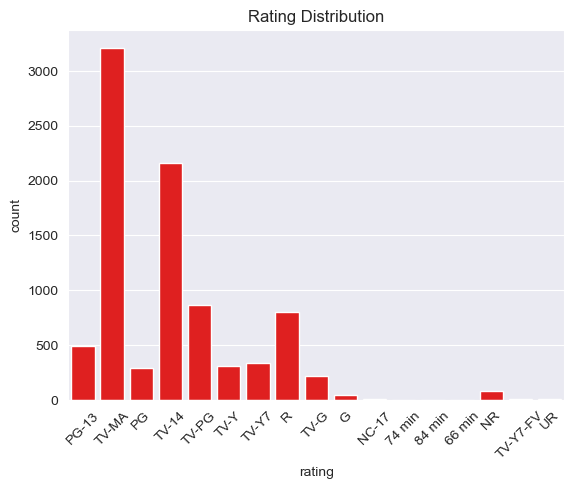

In [42]:
sns.countplot(x="rating", data=df, color="red")
plt.tick_params(axis="x", rotation=45)
plt.title("Rating Distribution")
plt.show()

#### Insight:

TV-MA has the highest the rating (3211) and the second most common is TV-14 (2160)

##### 4.Do Movies and Shows have different ratings

In [43]:
# type vs rating
df[["type","rating"]].value_counts()

type     rating  
Movie    TV-MA       2064
         TV-14       1427
TV Show  TV-MA       1147
Movie    R            797
TV Show  TV-14        733
Movie    TV-PG        540
         PG-13        490
TV Show  TV-PG        323
Movie    PG           287
TV Show  TV-Y7        195
         TV-Y         176
Movie    TV-Y7        139
         TV-Y         131
         TV-G         126
TV Show  TV-G          94
Movie    NR            75
         G             41
         TV-Y7-FV       5
TV Show  NR             5
Movie    NC-17          3
         UR             3
TV Show  R              2
Movie    66 min         1
         74 min         1
         84 min         1
TV Show  TV-Y7-FV       1
Name: count, dtype: int64

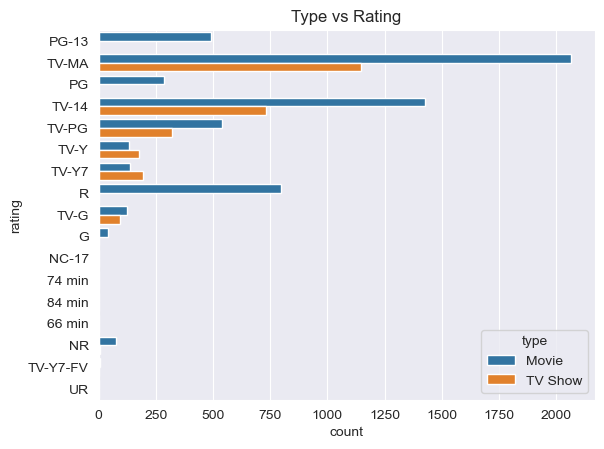

In [44]:
sns.countplot(y="rating", data=df, hue="type")
plt.title("Type vs Rating")
plt.show()

#### Insight :

Movies dominates most rating categories like TV MA and TV 14 which show adult content.

##### 5. Which countries produces more movies/shows

In [45]:
df[["country","type"]].value_counts()

country                                                                         type   
United States                                                                   Movie      2058
India                                                                           Movie       893
United States                                                                   TV Show     760
Unknown                                                                         Movie       440
                                                                                TV Show     391
                                                                                           ... 
Ireland, Canada                                                                 Movie         1
Ireland, Canada, Luxembourg, United States, United Kingdom, Philippines, India  Movie         1
Ireland, Canada, United Kingdom, United States                                  Movie         1
Ireland, Canada, United States, United Kingdom  

In [46]:
# For keeping top ten countries

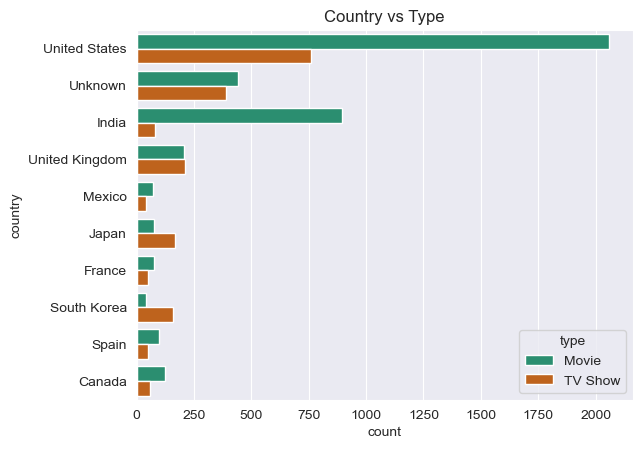

In [48]:
top10 = df["country"].value_counts().head(10).index
top_df = df[df["country"].isin(top10)]
sns.countplot(data=top_df,y="country",hue="type",palette="Dark2")
plt.title("Country vs Type")
plt.show()

#### Insight:

United State  produces the highest number of contents and india is second in terms of producing highest number of movies.

The Unknown countries (not mentioned in record) shows significant record in terms of producing movies and TV shoes

##### 6.Which year released more movies/shows

In [51]:
# keeping top ten release years
top_years = df["release_year"].value_counts().head(10).index
years_df = df[df["release_year"].isin(top_years)]

In [52]:
df[["type","release_year"]].value_counts()

type     release_year
Movie    2017            767
         2018            767
         2016            658
         2019            633
         2020            517
                        ... 
TV Show  1979              1
         1981              1
         1985              1
         1989              1
Movie    1959              1
Name: count, Length: 119, dtype: int64

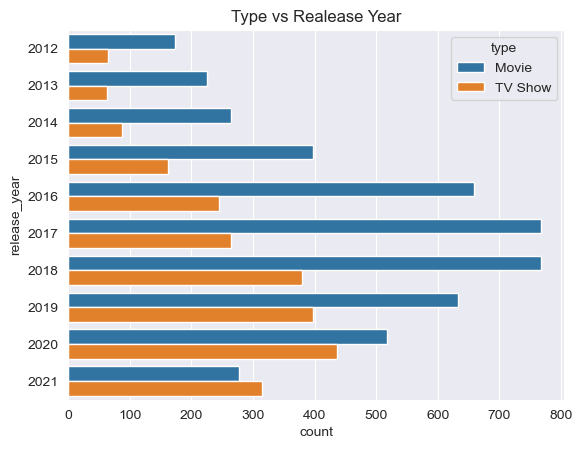

In [53]:
sns.countplot(data=years_df,y="release_year",hue="type")
plt.title("Type vs Realease Year")
plt.show()

#### Insight:

Years 2017 and 2018 has released most numbers of movies each (763) while 2020 released most numbers of TV Shows.

##### 7.Distribution of duration (Most Common duration)

In [54]:
top_duration = df["duration"].value_counts().head(10).index
duration_df = df[df["duration"].isin(top_duration)]

In [55]:
df["duration"].value_counts().head(10)

duration
1 Season     1796
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

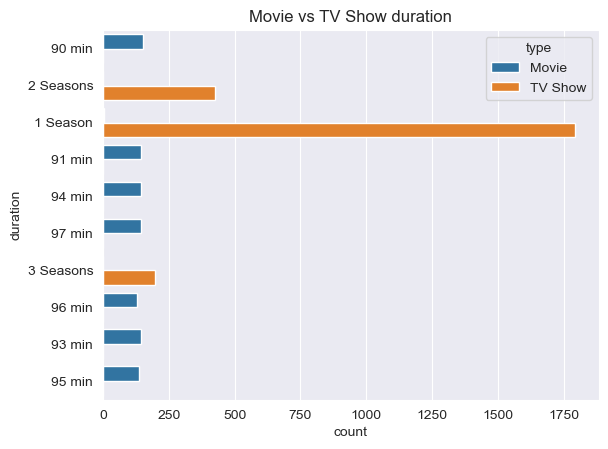

In [56]:
sns.countplot(y="duration",data=duration_df, hue="type")
plt.title("Movie vs TV Show duration")
plt.show()

#### Insights:

Most Movies duration lies between 90 to 9 minute while most tv shows ended in first season(1976)

##### 8.Top Countries producing content

In [57]:
countries = df["country"].value_counts().head(10)

In [58]:
countries

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

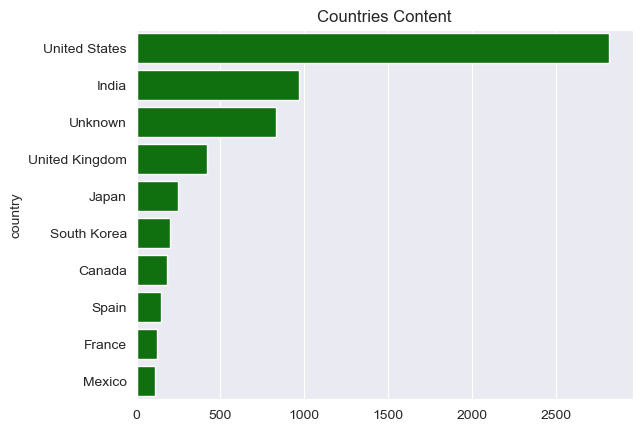

In [59]:
sns.barplot(x=countries.values,y=countries.index,color="green")
plt.title("Countries Content")
plt.show()

#### Insight:

United States tops by producing most content followed by India and some countries are not known yet they also ranks 3rd.

#### Conclusion

The analysis shows that Netflix's content library is dominated by movies, with most titles released between 2015 and 2020. TV-MA and TV-14 are the most common ratings, indicating a strong focus on mature audiences. The United States is the leading producer of Netflix content, followed by India. Additionally, movies dominate most rating categories, while the majority of TV shows consist of only one season. Overall, the dataset highlights Netflix's emphasis on movie content, recent releases, and audience-oriented program.